<h1> Practical 5 - MNIST and CNNs in PyTorch </h1>

In this practical you will utilise PyTorch to implement a convolutional neural network (CNN).
This notebook contains the relevant skeleton code, and you have been provided with the Numpy files containing the MNIST dataset.

**The practical comprises 4 questions and one optional question:**
1. Import data - this is already done.
2. Define CNN model structure
3. Train the CNN model
4. Visualise trained CNN filters
5. Visualise correlation matrices from different input digits.

In [1]:
# preamble - imports
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt

# load in helper functions from helper_functions.py
from helper_functions import read_npz,hits,plot_filters

# Question 1

Use the function `load_npz` to load the training and test partitions. Run the code section under the header **`Code checker question 1`** to verify your code has run correctly.

In [2]:
# read datasets
train_X,train_Y = read_npz("data/train.npz")
test_X,test_Y = read_npz("data/test.npz")

print("+" + 40 * '-')
print(f"| Train X: {train_X.shape}")
print(f"| Train Y: {train_Y.shape}")
print(f"| Test X: {test_X.shape}")
print(f"| Test Y: {test_Y.shape}")
print("+ " + 40 * '-')

+----------------------------------------
| Train X: torch.Size([60000, 784])
| Train Y: torch.Size([60000])
| Test X: torch.Size([10000, 784])
| Test Y: torch.Size([10000])
+ ----------------------------------------


## Code checker question 1

In [3]:
data_load_test_1 = train_X.shape == (60000,784) and train_Y.shape == (60000,)
data_load_test_2 = test_X.shape == (10000,784) and test_Y.shape == (10000,)

if (not data_load_test_1) or (not data_load_test_2):
    raise ValueError("Training or test data [X,Y] dimensions are incorrect")
else:
    print("+" + "-" * 40)
    print("| Data loaded in successfully.")
    print("+" + "-" * 40)

+----------------------------------------
| Data loaded in successfully.
+----------------------------------------


# Question 2.1 and 2.2

**2.1** In the demarcated space in the code-block below, define a CNN layer (`conv_1`), a Relu activation (`relu`), and a fully-connected linear layer (`dense`) according to the structure given.  Run the code section under the header **`Code checker question 2.1`** to verify your code has run correctly.

Note: your model should return `y_hat`, `z_1`, and `v_1` when called (i.e. `y_hat,z_1 ,v_1 = model(x)`. Additionally note that, in PyTorch, the model does not require a sigmoid or softmax activation on the output - this is included in the cross entropy loss implementation.

| Layer | Type | Input | Kernel | Num (C) | Stride | Activation | Layer Output |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 1 | CNN | (28 x 28 x 1) | (8 x 8 x ▢) | 10 | 2 | ReLU | (▢ x ▢ x 10) |  
| 2 | Dense | (▢) | - | - | - | - | (10) | 


**2.2** Again, in the demarcated space in the code-block below, utilise the defined layers to implement the forward pass calculations for the model structure. Run the code section under the header **`Code checker question 2.2`** to verify your code has run correctly.

In [4]:
####################################################################
#                         Define a CNN model                       #
####################################################################
class CNN(nn.Module):
    def __init__(self,M_1,M_2,M_3,K,stride):
        super().__init__() # initialise superclass (i.e. nn.Module)
        """CNN Network
        
        Arguments:
        ---------
            M_1 : int
                - CNN kernel 'height' dimension
            M_2 : int
                - CNN kernel 'width' dimension
            M_3 : int
                - CNN kernel output channels
            K : int
                - Model output dimensions
            stride : int
                - Step size for CNN kernel during correlation
        """
        
        ####################################################################
        #                     (2.1) Define CNN layers                      #
        ####################################################################

        self.conv_1 = nn.Conv2d(in_channels=1, out_channels=M_3, kernel_size=(M_1, M_2), stride=stride)
        self.relu_1 = nn.ReLU()

        Q1 = (28 - M_1) // stride + 1
        Q2 = (28 - M_2) // stride + 1
        dense_input_size = Q1 * Q2 * M_3

        self.dense = nn.Linear(in_features=dense_input_size, out_features=K)

        #*************************** YOUR CODE HERE ***********************#


        #******************************************************************#

    def forward(self, x):
        """
        Arguments:
            x : Input vector (N,D)

        Returns:
            y_hat : torch.tensor
                - Output predcition (N,K)
            
            z_1 : torch.tensor
                - Output matrix after convolutional layer

            v_1 : torch.tensor
                - Output matrix after activation layer
        
        Notes:
            Data is currently in format (N,D) where D = 784
            but we need 28x28 images for CNN
            dimensionality required by CNN input is: (B,C,H,W)
                B is batch size
                C (M_3) is channels
                H (M_1) is height
                W (M_2) is width
        """

       


        ####################################################################
        #                  (2.2) Define CNN forward pass                   #
        ####################################################################

        #*************************** YOUR CODE HERE ***********************#
        x_reshaped = x.view(-1, 1, 28, 28) # reshape input to (B,C,H,W)
        z_1 = self.conv_1(x_reshaped) # convolutional layer
        v_1 = self.relu_1(z_1) # activation layer
        v_1_flat = v_1.view(v_1.size(0), -1) 

        y_hat = self.dense(v_1_flat) # dense layer

        #******************************************************************#

        return y_hat,z_1,v_1

## Code checker question 2.1 

In [5]:
torch.manual_seed(42) # set seed for reproducibility

m = CNN(8,8,10,10,2) # define model
test_model = [type(l) for l in m.modules()]
layers_test_1 = nn.ReLU in test_model
layers_test_2 = nn.Linear in test_model
layers_test_3 = nn.Conv2d in test_model

if (not layers_test_1) or (not layers_test_2) or (not layers_test_3):
    raise ValueError("Model does not contain the correct layer types.")
else:
    print("Model contains the correct layers.")
    print("Comment the exit() command below to continue to question 2(b).")
    print("*" * 40)

Model contains the correct layers.
Comment the exit() command below to continue to question 2(b).
****************************************


## Code checker question 2.2

In [6]:
dummy_input = torch.ones((784,))
y_hat,z_1,v_1 = m(dummy_input)
if (not torch.round(y_hat.mean(), decimals=2) == 0.03 or \
    (not y_hat.shape == (1,10))):
    raise ValueError("Model does not produce the expected output")
elif (not torch.round(z_1.mean(), decimals=2) == -0.41 or \
    (not z_1.shape == (1,10,11,11))):
    raise ValueError("Model does not produce the expected output")
elif (not torch.round(v_1.mean(), decimals=2) == 0.09 or \
    (not v_1.shape == (1,10,11,11))):
    raise ValueError("Model does not produce the expected output")
else:
    print("+" + "-" * 40)
    print("| Model produces the expected output after the forward pass.")
    print("+" + "-" * 40)

+----------------------------------------
| Model produces the expected output after the forward pass.
+----------------------------------------


# Question 2.3

Now, in the demarcated space in the code-block below, instantiate the CNN model, cross-entropy loss function, and an SGD optimizer.

In [7]:
####################################################################
#           (2.3) Instantiate CNN model and loss function          #
####################################################################

model = None # empty variable - you should name your model this
optimizer = None # empty variable - you should name your optimizer this
lr = 0.01 # learning rate for training
epochs = 10 # number of epochs to train for
batch_size = 30 # batch size for training
num_training_samples = train_X.shape[0] # number of samples in the training set
num_test_samples = test_X.shape[0] # number of samples in the test set

#*************************** YOUR CODE HERE ***********************#

model = CNN(M_1=8, M_2=8, M_3=10, K=10, stride=2)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=lr)

#******************************************************************#

print(model) # print out model summary



CNN(
  (conv_1): Conv2d(1, 10, kernel_size=(8, 8), stride=(2, 2))
  (relu_1): ReLU()
  (dense): Linear(in_features=1210, out_features=10, bias=True)
)


# Question 3.1, 3.2, 3.3

In the following code-block implement:

* **3.1** The forward pass, model loss, and backward pass for the training set.
* **3.2** The code to update model parameters.
* **3.3** The forward pass and model loss for the test set.

In [10]:
####################################################################
#                       Train the CNN model                        #
####################################################################

print(40 * "*")
print("Beginning training")
for epoch in range(epochs):

    ##########################################
    #             training loop              #
    ##########################################
    train_loss = 0.
    train_accuracy = 0.
    for i in range(num_training_samples//batch_size):
        X_i = train_X[None,i:i+batch_size,:] # extract i'th input batch from training set
        y_i = train_Y[i:i+batch_size] # extract i'th target batch from training set

        loss = None # empty variable - you should calculate the batch loss
        y_hat = None # empty variable - you should calculate the model prediction

        ####################################################################
        #       (3.1) Implement forward pass, loss calculation,            #
        #                       and backward pass                          #
        ####################################################################

        #*************************** YOUR CODE HERE ***********************#
        optimizer.zero_grad() # zero the gradients before backward pass
        y_hat,z_1,v_1 = model(X_i) # forward pass
        loss = loss_fn(y_hat, y_i) # calculate batch loss
        loss.backward() # backward pass to calculate gradients

        #******************************************************************#

        ####################################################################
        #                     (3.2) Update model parameters                #
        ####################################################################
        
        #*************************** YOUR CODE HERE ***********************#
        optimizer.step() # update model parameters using calculated gradients

        #******************************************************************#  
        
        # stops variables being added to computational graph
        with torch.no_grad():
            # track the training loss and accuracy
            train_loss += loss
            train_accuracy += hits(y_hat,y_i)
                      

    ##########################################
    #               test loop                #
    ##########################################
    test_loss = 0.
    test_accuracy = 0.
    with torch.no_grad():
        for i in range(num_test_samples//100):
            X_i = test_X[None,i:i+100,:] # extract i'th input batch from test set
            y_i = test_Y[i:i+100] # extract i'th target batch from training set

            loss = None # empty variable - you should calculate the batch loss
            y_hat = None # empty variable - you should calcualte the model prediction

            ####################################################################
            #       (3.3) Calculate forward pass, loss, and backward pass      #
            ####################################################################

            #*************************** YOUR CODE HERE ***********************#
            y_hat,z_1,v_1 = model(X_i) # forward pass
            loss = loss_fn(y_hat, y_i) # calculate batch loss

            #******************************************************************#

            # track the test loss and accuracy
            test_loss += loss
            test_accuracy += hits(y_hat,y_i)

    # print epoch performance
    train_loss /= num_training_samples # calculate average loss
    train_accuracy /= num_training_samples / 100 # calculate percentage accuracy
    test_loss /= num_test_samples # calculate average loss
    test_accuracy /= num_test_samples / 100 # calculate percentage accuracy
    print(f"Epoch {epoch+1} Loss: {train_loss:.4f} Accuracy: {train_accuracy:.2f} " +
          f"Test Loss: {test_loss:.4f} Test Accuracy: {test_accuracy:.2f}")

****************************************
Beginning training
Epoch 1 Loss: 0.0006 Accuracy: 99.78 Test Loss: 0.0022 Test Accuracy: 92.10
Epoch 2 Loss: 0.0005 Accuracy: 99.82 Test Loss: 0.0021 Test Accuracy: 93.50
Epoch 3 Loss: 0.0004 Accuracy: 99.85 Test Loss: 0.0019 Test Accuracy: 93.58
Epoch 4 Loss: 0.0004 Accuracy: 99.89 Test Loss: 0.0018 Test Accuracy: 93.79
Epoch 5 Loss: 0.0003 Accuracy: 99.90 Test Loss: 0.0017 Test Accuracy: 93.79
Epoch 6 Loss: 0.0003 Accuracy: 99.92 Test Loss: 0.0016 Test Accuracy: 93.79
Epoch 7 Loss: 0.0003 Accuracy: 99.92 Test Loss: 0.0016 Test Accuracy: 95.46
Epoch 8 Loss: 0.0002 Accuracy: 99.94 Test Loss: 0.0015 Test Accuracy: 95.46
Epoch 9 Loss: 0.0002 Accuracy: 99.95 Test Loss: 0.0015 Test Accuracy: 95.46
Epoch 10 Loss: 0.0002 Accuracy: 99.95 Test Loss: 0.0014 Test Accuracy: 95.46


# Question 4

Finally, utilising the trained model calculate the model outputs (`y_hat,z_1,v_1`) and then utilise the provided function `plot_filters(X,H,z_1,v_1)` to visualise the filters, correlations and output matrices for the trained model.

**Discuss briefly what you see.** Consult the inline comments for detailed explanation of the required inputs.

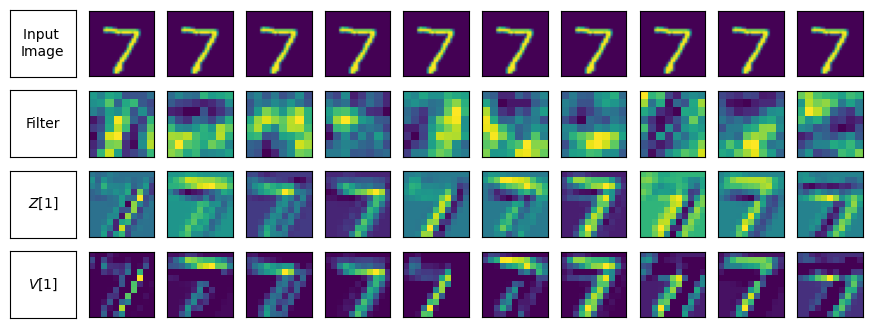

In [13]:
####################################################################
#    (4) Calculate forward pass for first example from test set    #
#        use `plot_filters` to visualise the CNN filters and       #
#        correlations, output plot is saved in `filters.png`       #
#                                                                  #
#                                                                  #
#           plot_filters arguments :                               #
#               X : torch.tensor                                   #
#                   - Feature vector with D dimensions             #
#               H : torch.tensor                                   #
#                   - CNN weights/filters with dimensions          #
#                     (C,M_3,M_1,M_2)                              #
#               z_1 : torch.tensor                                 #
#                   - CNN layer one output after bias with         #
#                     dimensions (B,C,Q_1,Q_2)                     #
#               v_1 : torch.tensor                                 #
#                   - CNN layer one output after activation        #
#                     function with dimensions (B,C,Q_1,Q_2)       #
#                                                                  #
#               D : total number of input features                 #
#               C : number of filters/channels in CNN              #
#               M : kernel size                                    #
#               B : number of examples in minibatch                #
####################################################################

X = test_X[0,:] # example to be fed to your model


#*************************** YOUR CODE HERE ***********************#
x_input = X[None,:] # reshape input to (1,D)
y_hat,z_1,v_1 = model(x_input) # forward pass for first example in test set

with torch.no_grad():
    y_hat,z_1,v_1 = model(x_input)

H = model.conv_1.weight

plot_filters(x_input, H, z_1, v_1) # visualise filters and correlations

#******************************************************************#

# Question 5 (Optional)

Experiment with visualising the results of the forward calculations for different input images. Again, briefly discuss what you see.

**Note:** If you would like to experiment with different model architectures, do not run the code checker sections they will produce errors.

Index 2 | True Class: 1 | Predicted Class: 1


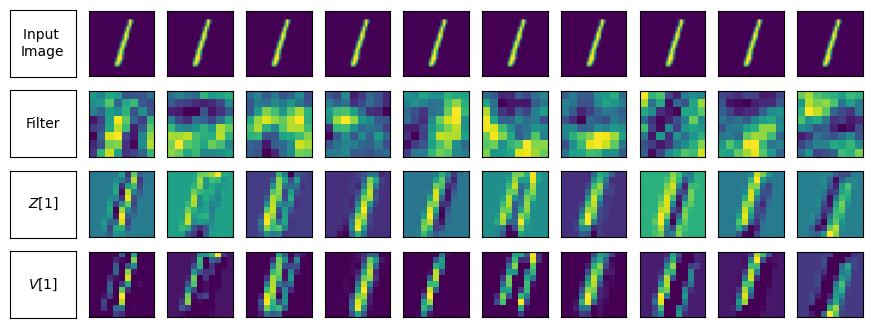

Index 3 | True Class: 0 | Predicted Class: 0


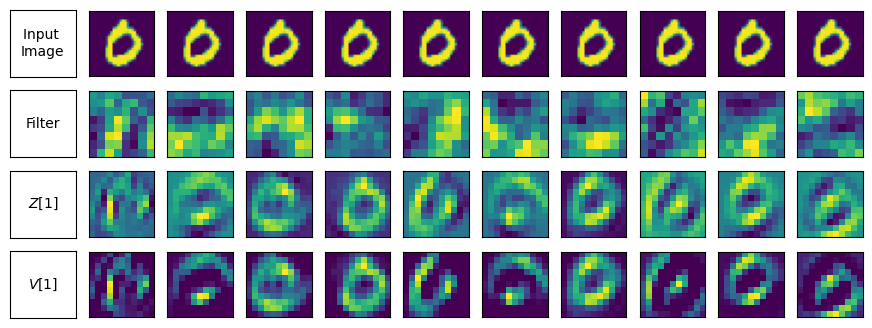

Index 5 | True Class: 1 | Predicted Class: 1


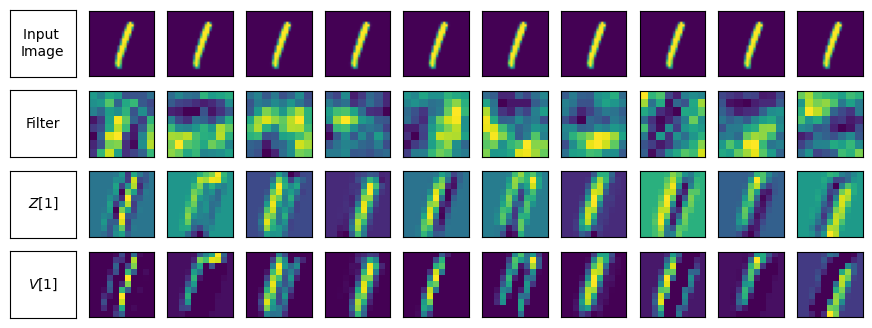

In [14]:
indices_to_test = [2, 3, 5] 

for idx in indices_to_test:
    X_experiment = test_X[idx,:]
    
    X_input = X_experiment.unsqueeze(0)
    
    with torch.no_grad():
        y_hat, z_1, v_1 = model(X_input)
        
    H = model.conv_1.weight
    
    predicted_class = torch.argmax(y_hat, dim=-1).item()
    true_class = test_Y[idx].item()
    print(f"Index {idx} | True Class: {true_class} | Predicted Class: {predicted_class}")
    
    plot_filters(X_experiment, H, z_1, v_1)
    plt.show()